# 01e -- Baseline LSTM-VAE v3 | SWaT A1/A2 (Hibrido + Eval Pinto et al.)

Combina la **arquitectura hibrida propia** (LSTM continuas + MLP discretas) con la
**metodologia de evaluacion de Pinto et al. (2024)**, permitiendo comparacion directa
con los resultados publicados por la asesora.

| Componente | Origen | Detalle |
|---|---|---|
| Arquitectura LSTM cont + MLP disc | Propio | Se mantiene intacta |
| Feature engineering RWSF + TF | Pinto et al. | 25 -> 89 continuas (LSTM branch) |
| Discretas: normalizacion max | Propio | Sin StandardScaler (preserva representacion) |
| Warmup 118,000 s desde v1 | Pinto et al. | (6h - 30min) + 98,200 s estabilizacion |
| Score alpha*MAE | Pinto et al. | Mas robusto que MSE ante outliers |
| 26 ataques evaluables | Pinto et al. | Excluye 15 sin impacto fisico / fallidos |

**Referencia:** Pinto et al. (2024): AUC=0.87 | F1=0.74 | Recall=0.78 | Precision=0.70


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

CLEAN_DIR   = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A1 & A2_Dec 2015'
NORMAL_XLSX = CLEAN_DIR / 'SWaT_Dataset_Normal_v1.xlsx'
ATTACK_XLSX = CLEAN_DIR / 'SWaT_Dataset_Attack_v0.xlsx'

OPTUNA_CFG  = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_swat_a1a2_optuna_v1' / 'optuna_best_config.json'
SAVE_DIR    = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_swat_a1a2_baseline_v3'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('Normal :', NORMAL_XLSX.exists())
print('Attack :', ATTACK_XLSX.exists())
print('Optuna :', OPTUNA_CFG.exists())
print('Save   :', SAVE_DIR)
ATK_LIST  = CLEAN_DIR / 'List_of_attacks_Final.xlsx'
print('ATK_LIST  :', ATK_LIST.exists())


Normal : True
Attack : True
Optuna : True
Save   : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_baseline_v3
ATK_LIST  : True


## 2. Hiperparametros (Optuna + constantes FE + eval Pinto)

In [107]:
with open(OPTUNA_CFG) as f:
    ocfg = json.load(f)

CONTINUOUS_COLS = ocfg['continuous_cols']
DISCRETE_COLS   = ocfg['discrete_cols']
ALL_SENSOR_COLS = CONTINUOUS_COLS + DISCRETE_COLS
DISC_DIM        = int(ocfg['disc_summary_dim'])

bp = ocfg['best_params']
WINDOW_SIZE  = 10
STRIDE       = 1
CLIP_VAL     = float(ocfg['clip_val'])
WARMUP_SEC   = int(ocfg['warmup_sec'])
CONSEC_K     = 3

HIDDEN_SIZE  =256
NUM_LAYERS   = 2
LATENT_DIM   = 196
DISC_HIDDEN  = int(bp['disc_hidden'])
BETA         = float(bp['beta'])
ALPHA        = float(bp['alpha'])
DROPOUT      = float(bp['dropout'])
LR           = float(bp['lr'])
BATCH_SIZE   = 1024

MAX_EPOCHS   = 150
PATIENCE     = 20

print(f'--- Configuracion cargada del mejor trial Optuna (#{ocfg["best_trial"]}) ---')
print(f'AUC en Optuna (trial)     : {ocfg["best_auc_trial"]:.4f}')
print(f'AUC en Optuna (retrain)   : {ocfg["best_auc_retrain"]:.4f}')
print(f'Window={WINDOW_SIZE} | Stride={STRIDE} | Clip={CLIP_VAL} | K={CONSEC_K}')
print(f'hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM} | disc_h={DISC_HIDDEN}')
print(f'beta={BETA:.5f} | alpha={ALPHA:.4f} | dropout={DROPOUT:.4f}')
print(f'lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'Sensores: {len(CONTINUOUS_COLS)} cont + {len(DISCRETE_COLS)} disc')

# ── Feature engineering (Pinto et al.) ────────────────────────────────────
SEASONAL_SENSORS = ['FIT101','LIT101','FIT201','DPIT301','FIT301','LIT301','AIT401','FIT601']
RWSF_WINDOW      = 120    # segundos
TF_LAGS          = [10, 20, 30]  # segundos

RWSF_COLS = [f'{s}_{st}' for s in SEASONAL_SENSORS
             for st in ['roll_mean','roll_median','roll_std','roll_max','roll_min']]
TF_COLS   = [f'{s}_lag_{lag}' for s in SEASONAL_SENSORS for lag in TF_LAGS]
CONT_FEAT_COLS = CONTINUOUS_COLS + RWSF_COLS + TF_COLS  # 25+40+24=89

# ── Evaluacion alineada con Pinto et al. (2024) ─────────────────────────────
# Mismos 15 ataques excluidos: sin impacto fisico, fallidos, malfunctions
EXCLUDED_ATTACKS  = [4, 5, 6, 9, 12, 13, 14, 15, 18, 19, 20, 24, 29, 34, 38]
EVALUABLE_ATK_IDS = [i for i in range(1, 42) if i not in EXCLUDED_ATTACKS]
WARMUP_SEC        = 118000  # (6h - 30min) desde v1 + 98,200 s est. sensores

print(f'CONT_FEAT_COLS: {len(CONT_FEAT_COLS)} (25 orig + 40 RWSF + 24 TF)')
print(f'DISCRETE_COLS : {len(DISCRETE_COLS)}')
print(f'Ataques evaluables: {len(EVALUABLE_ATK_IDS)} / 41')


--- Configuracion cargada del mejor trial Optuna (#13) ---
AUC en Optuna (trial)     : 0.8314
AUC en Optuna (retrain)   : 0.8216
Window=10 | Stride=1 | Clip=5.0 | K=3
hidden=256 | layers=2 | latent=196 | disc_h=128
beta=0.06728 | alpha=0.8775 | dropout=0.2641
lr=1.60e-04 | batch=1024
Sensores: 25 cont + 26 disc
CONT_FEAT_COLS: 89 (25 orig + 40 RWSF + 24 TF)
DISCRETE_COLS : 26
Ataques evaluables: 26 / 41


## 3. Carga del dataset Normal_v1 y Attack_v0

In [5]:
def load_swat_xlsx(path, label_is_string=True):
    df = pd.read_excel(path, header=1)
    df.columns = [c.strip() for c in df.columns]
    df['Timestamp'] = pd.to_datetime(
        df['Timestamp'].astype(str).str.strip(),
        format='%d/%m/%Y %I:%M:%S %p'
    )
    df = df.sort_values('Timestamp').reset_index(drop=True)
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if label_is_string and 'Normal/Attack' in df.columns:
        df['Normal/Attack'] = df['Normal/Attack'].astype(str).str.strip().replace('A ttack','Attack')
        df['attack_label']  = (df['Normal/Attack'] == 'Attack').astype(int)
    else:
        df['attack_label'] = 0
    return df

print('Cargando Normal_v1...')
df_normal = load_swat_xlsx(NORMAL_XLSX, label_is_string=False)
t0_n = df_normal['Timestamp'].min()
df_normal = df_normal[
    df_normal['Timestamp'] >= t0_n + pd.Timedelta(seconds=WARMUP_SEC)
].reset_index(drop=True)

n = len(df_normal)
df_train = df_normal.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_normal.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_normal.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f'  Normal_v1: {len(df_normal):,} filas | '
      f'{df_normal["Timestamp"].min()} -> {df_normal["Timestamp"].max()}')
print(f'  Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

print('Cargando Attack_v0...')
df_attack = load_swat_xlsx(ATTACK_XLSX, label_is_string=True)
print(f'  Attack_v0: {len(df_attack):,} filas | '
      f'Normal={(df_attack["attack_label"]==0).sum():,} | '
      f'Attack={(df_attack["attack_label"]==1).sum():,} ({100*df_attack["attack_label"].mean():.1f}%)')


Cargando Normal_v1...
  Normal_v1: 377,000 filas | 2015-12-24 01:16:40 -> 2015-12-28 09:59:59
  Train: 226,200 | Val: 75,400 | Test: 75,400
Cargando Attack_v0...
  Attack_v0: 449,919 filas | Normal=395,298 | Attack=54,621 (12.1%)


## 4. Feature Engineering

Se agregan 64 features a las 25 continuas originales:
- **RWSF (40)**: media, mediana, std, max, min con ventana de 120 s sobre 8 sensores estacionales
- **TF (24)**: lags de 10, 20, 30 s sobre los mismos 8 sensores

Las 26 variables discretas (actuadores) NO reciben FE ya que se resumen
por ventana (mode, transitions, nunique, dominance) en la branch MLP.


In [6]:
# ── Feature engineering (RWSF + TF sobre sensores estacionales) ────────────
def add_feat_eng(df, sensor_cols):
    """Agrega 40 RWSF + 24 TF a las columnas originales.
    Solo se aplica sobre SEASONAL_SENSORS (continuas con estacionalidad).
    Las variables discretas no se modifican.
    """
    df = df.copy()
    for s in SEASONAL_SENSORS:
        if s not in sensor_cols: continue
        r = df[s].rolling(RWSF_WINDOW, min_periods=1)
        df[f'{s}_roll_mean']   = r.mean()
        df[f'{s}_roll_median'] = r.median()
        df[f'{s}_roll_std']    = r.std().fillna(0)
        df[f'{s}_roll_max']    = r.max()
        df[f'{s}_roll_min']    = r.min()
    for s in SEASONAL_SENSORS:
        if s not in sensor_cols: continue
        for lag in TF_LAGS:
            df[f'{s}_lag_{lag}'] = df[s].shift(lag).bfill()
    return df

print('Aplicando feature engineering a Normal_v1...')
df_normal_fe = add_feat_eng(df_normal, CONTINUOUS_COLS)
n = len(df_normal_fe)
df_train = df_normal_fe.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_normal_fe.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_normal_fe.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f'  FE generado: {len(CONT_FEAT_COLS)} continuas + {len(DISCRETE_COLS)} discretas')
print(f'  Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
nan_count = df_train[CONT_FEAT_COLS].isna().sum().sum()
print(f'  NaN en CONT_FEAT_COLS train: {nan_count}  (esperado: 0)')


Aplicando feature engineering a Normal_v1...
  FE generado: 89 continuas + 26 discretas
  Train: 226,200 | Val: 75,400 | Test: 75,400
  NaN en CONT_FEAT_COLS train: 0  (esperado: 0)


## 5. Escalado

- **Continuas (89)**: `StandardScaler` fiteado en train.
- **Discretas (26)**: division por maximo del train -> rango `[0, 1]`. **No se usa
  StandardScaler** porque convertiria valores binarios `{0, 1}` en flotantes
  arbitrarios, destruyendo la representacion semantica de los actuadores.


In [7]:
# Continuas (89 = 25 orig + 40 RWSF + 24 TF): StandardScaler
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[CONT_FEAT_COLS].values)

# Discretas (26): normalizacion por maximo del train
disc_max = df_train[DISCRETE_COLS].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[CONT_FEAT_COLS] = np.clip(
        scaler_cont.transform(df[CONT_FEAT_COLS].values), -CLIP_VAL, CLIP_VAL
    )
    df[DISCRETE_COLS] = (df[DISCRETE_COLS] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')

rc = df_train_sc[CONT_FEAT_COLS].values
rd = df_train_sc[DISCRETE_COLS].values
print(f'Continuas ({len(CONT_FEAT_COLS)}) escaladas: [{rc.min():.2f}, {rc.max():.2f}]')
print(f'Discretas ({len(DISCRETE_COLS)}) norm [0,1]: [{rd.min():.2f}, {rd.max():.2f}]')


Continuas (89) escaladas: [-5.00, 5.00]
Discretas (26) norm [0,1]: [0.00, 1.00]


## 6. Ventanas de entrenamiento (N, T, 89) continuas + disc summary

In [8]:
def create_windows_fast(arr, ws, stride):
    """np.lib.stride_tricks: O(1) memoria extra, muy rapido."""
    n, c = arr.shape
    idx = np.arange(0, n - ws + 1, stride)
    # Construir indice de forma vectorizada
    rows = idx[:, None] + np.arange(ws)[None, :]    # (N, ws)
    return arr[rows].astype(np.float32)              # (N, ws, c)

def summarize_discrete_windows_fast(disc_windows):
    """Version vectorizada: de O(N*T*D) Python a numpy puro.
    disc_windows: (N, T, D) float32
    """
    # Valores medios por ventana (proporcion de 1s en variables binarias)
    mean_vals = disc_windows.mean(axis=1)                                # (N, D)
    # Mode: redondear la media (valido para binarias {0,1})
    mode_vals = np.round(mean_vals).astype(np.float32)                  # (N, D)
    # Transitions: cambios entre timesteps consecutivos
    diffs = np.abs(np.diff(disc_windows, axis=1)) > 0                   # (N, T-1, D)
    transitions = diffs.sum(axis=1).astype(np.float32)                  # (N, D)
    # Nunique: 1 si constante, 2 si cambio alguna vez
    nunique = (transitions > 0).astype(np.float32) + 1.0               # (N, D)
    # Dominance: max(mean, 1-mean) -- fraccion del valor dominante
    dominance = np.maximum(mean_vals, 1.0 - mean_vals).astype(np.float32) # (N, D)
    # Concatenar: 4 stats x D cols = 4*26 = 104 features
    return np.concatenate([mode_vals, transitions, nunique, dominance], axis=1)

def build_windows(df_sc, ws, stride):
    # Continuas: CONT_FEAT_COLS (89) -> LSTM branch
    wc  = create_windows_fast(df_sc[CONT_FEAT_COLS].values.astype(np.float32), ws, stride)
    # Discretas: DISCRETE_COLS (26) -> summary stats -> MLP branch
    wd  = create_windows_fast(df_sc[DISCRETE_COLS].values.astype(np.float32),  ws, stride)
    wds = summarize_discrete_windows_fast(wd)
    return wc, wds

X_tr_c, X_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows(df_test_sc,  WINDOW_SIZE, STRIDE)

DISC_DIM_ACTUAL = X_tr_d.shape[1]  # 26*4 = 104
print(f'Train: {X_tr_c.shape}  (N, T, 89)')
print(f'Val  : {X_va_c.shape}')
print(f'Test : {X_te_c.shape}')
print(f'Disc summary dim: {DISC_DIM_ACTUAL}  (26 vars x 4 stats)')


Train: (226191, 10, 89)  (N, T, 89)
Val  : (75391, 10, 89)
Test : (75391, 10, 89)
Disc summary dim: 104  (26 vars x 4 stats)


## 7. Arquitectura LSTM-VAE Hibrida

```
Continuas (N, 60, 89) -> LSTMEncoder -> mu, logvar -> z
                                                        |
                                                        v
                                               LSTMDecoder -> x_hat (N, 60, 89)

Discretas summary (N, 104) -> MLPEncoder -> MLPDecoder -> xd_hat
```
Score anomalia: `alpha * MAE_cont + (1-alpha) * MAE_disc`


In [9]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, seq_len, disc_dim, hidden_size=128, num_layers=2,
                 latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        cont_size = len(CONT_FEAT_COLS)  # 89: 25 orig + 40 RWSF + 24 TF
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha*(mse_c + beta*kl) + (1-alpha)*mse_d, mse_c, mse_d, kl

model = HybridLSTMVAE(
    seq_len     = WINDOW_SIZE,
    disc_dim    = DISC_DIM_ACTUAL,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales: {n_params:,}')
print(f'  Encoder LSTM (cont=89): {sum(p.numel() for p in model.encoder_cont.parameters()):,}')
print(f'  Decoder LSTM          : {sum(p.numel() for p in model.decoder_cont.parameters()):,}')
print(f'  MLP disc              : {sum(p.numel() for p in model.encoder_disc.parameters())+sum(p.numel() for p in model.decoder_disc.parameters()):,}')


Parametros totales: 2,090,377
  Encoder LSTM (cont=89): 982,408
  Decoder LSTM          : 1,064,537
  MLP disc              : 43,432


## 8. Entrenamiento

In [10]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                  torch.tensor(X_tr_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                  torch.tensor(X_va_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-7
)

best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
train_hist, val_hist, hist_mse_c, hist_mse_d, hist_kl = [], [], [], [], []

print(f'Batch={BATCH_SIZE} | LR={LR:.2e} | MaxEp={MAX_EPOCHS} | Patience={PATIENCE}')
print(f'beta={BETA:.5f} | alpha={ALPHA:.4f}')
print(f'Train batches/ep: {len(train_loader):,}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    tl = tmse_c = tmse_d = tkl = 0.0
    for xc, xd in train_loader:
        xc, xd = xc.to(device), xd.to(device)
        optimizer.zero_grad()
        xc_hat, xd_hat, mu, logvar = model(xc, xd)
        loss, mc, md, kl = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        tl += loss.item(); tmse_c += mc.item(); tmse_d += md.item(); tkl += kl.item()

    nb_b = len(train_loader)
    tl /= nb_b; tmse_c /= nb_b; tmse_d /= nb_b; tkl /= nb_b

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xc, xd in val_loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0].item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    hist_mse_c.append(tmse_c); hist_mse_d.append(tmse_d); hist_kl.append(tkl)

    if vl < best_val - 1e-6:
        best_val = vl; best_ep = epoch; no_improve = 0
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} '
              f'(mse_c={tmse_c:.4f} kl={tkl:.4f}) | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
    if no_improve >= PATIENCE:
        print(f'Early stop ep{epoch}.'); break

model.load_state_dict(best_wts)
model.eval()
print(f'Mejor val:{best_val:.5f} ep{best_ep}')


Batch=1024 | LR=1.60e-04 | MaxEp=150 | Patience=20
beta=0.06728 | alpha=0.8775
Train batches/ep: 220
Ep   10/150 | Train:0.08292 (mse_c=0.0795 kl=0.2177) | Val:0.09570 | Best:0.09570(ep10)
Ep   20/150 | Train:0.06409 (mse_c=0.0639 kl=0.1340) | Val:0.08070 | Best:0.08070(ep20)
Ep   30/150 | Train:0.05683 (mse_c=0.0571 kl=0.1134) | Val:0.07503 | Best:0.07304(ep28)
Ep   40/150 | Train:0.05323 (mse_c=0.0536 kl=0.1048) | Val:0.07068 | Best:0.07068(ep40)
Ep   50/150 | Train:0.05117 (mse_c=0.0513 kl=0.1041) | Val:0.06687 | Best:0.06687(ep50)
Ep   60/150 | Train:0.04985 (mse_c=0.0499 kl=0.1018) | Val:0.06670 | Best:0.06545(ep58)
Ep   70/150 | Train:0.04889 (mse_c=0.0490 kl=0.0996) | Val:0.06408 | Best:0.06408(ep70)
Ep   80/150 | Train:0.04830 (mse_c=0.0483 kl=0.1007) | Val:0.06304 | Best:0.06304(ep80)
Ep   90/150 | Train:0.04809 (mse_c=0.0479 kl=0.1018) | Val:0.06350 | Best:0.06281(ep89)
Ep  100/150 | Train:0.04732 (mse_c=0.0472 kl=0.1002) | Val:0.06312 | Best:0.06264(ep97)
Ep  110/150 | Train

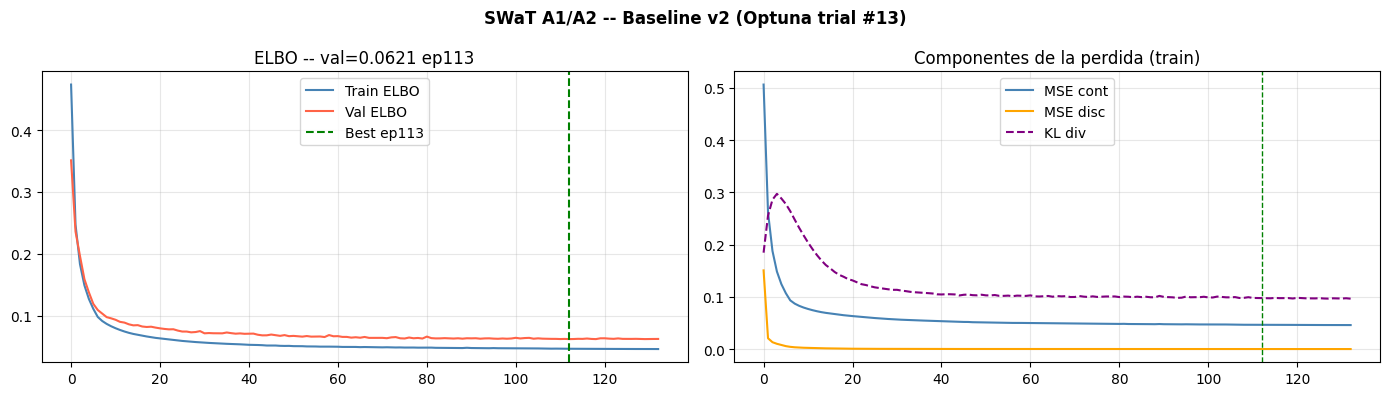

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_hist, label='Train ELBO', color='steelblue', lw=1.5)
axes[0].plot(val_hist,   label='Val ELBO',   color='tomato',    lw=1.5)
axes[0].axvline(best_ep-1, color='green', linestyle='--', lw=1.5, label=f'Best ep{best_ep}')
axes[0].set_title(f'ELBO -- val={best_val:.4f} ep{best_ep}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_mse_c, label='MSE cont', color='steelblue', lw=1.5)
axes[1].plot(hist_mse_d, label='MSE disc', color='orange',    lw=1.5)
axes[1].plot(hist_kl,    label='KL div',   color='purple',    lw=1.5, linestyle='--')
axes[1].axvline(best_ep-1, color='green', linestyle='--', lw=1)
axes[1].set_title('Componentes de la perdida (train)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'SWaT A1/A2 -- Baseline v2 (Optuna trial #{ocfg["best_trial"]})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()


## 9. Evaluacion supervisada -- Attack_v0

### 9a. Carga lista de ataques y ventanas de evaluacion

Se asigna `attack_id` a cada fila usando los timestamps de `List_of_attacks_Final.xlsx`,
permitiendo calcular deteccion por escenario (alineada con Tabla 3 de Pinto et al.).


In [12]:
# Cargar lista de ataques y parsear timestamps
df_atk_list = pd.read_excel(ATK_LIST)
df_atk_list = df_atk_list[
    pd.to_numeric(df_atk_list['Attack #'], errors='coerce').notna()
].copy()
df_atk_list['Attack #'] = df_atk_list['Attack #'].astype(int)
df_atk_list['start_dt'] = pd.to_datetime(
    df_atk_list['Start Time'].astype(str).str.strip(), errors='coerce'
)

# Fix para ataques en frontera de año (diciembre 2015 / enero 2016)
def parse_end_fixed(row):
    et = str(row['End Time']).strip()
    if et in ('nan', 'NaT', ''): return pd.NaT
    st = row['start_dt']
    if pd.isna(st): return pd.NaT
    try:
        t   = pd.to_datetime(et, format='%H:%M:%S').time()
        end = pd.Timestamp.combine(st.date(), t)
        # Si la hora de fin es menor que la de inicio, cruza medianoche
        if end < st:
            end += pd.Timedelta(days=1)
        return end
    except:
        return pd.NaT

# Aplicar FE y escalar el CSV de ataques con el mismo pipeline que el train
df_attack_fe = add_feat_eng(df_attack, CONTINUOUS_COLS)
df_eval_sc   = scale_df(df_attack_fe)

# Ataques 37-41 ocurren en enero 2016; si start_dt viene como 2015, corregir
for idx, row in df_atk_list.iterrows():
    if pd.notna(row['start_dt']) and row['start_dt'].year == 2015:
        # Verificar si debería ser 2016 comparando con el rango del CSV
        ts_max = df_eval_sc['Timestamp'].max()
        if ts_max.year == 2016 and row['start_dt'].month == 1:
            df_atk_list.at[idx, 'start_dt'] = row['start_dt'].replace(year=2016)

df_atk_list['end_dt'] = df_atk_list.apply(parse_end_fixed, axis=1)

# Asignar attack_id por timestamps
df_eval_sc['attack_id'] = 0
for _, row in df_atk_list.iterrows():
    aid = int(row['Attack #'])
    if pd.isna(row['start_dt']) or pd.isna(row['end_dt']): continue
    mask = ((df_eval_sc['Timestamp'] >= row['start_dt']) &
            (df_eval_sc['Timestamp'] <= row['end_dt']))
    df_eval_sc.loc[mask, 'attack_id'] = aid

# Construir ventanas de evaluacion
cont_arr  = df_eval_sc[CONT_FEAT_COLS].values.astype(np.float32)
disc_arr  = df_eval_sc[DISCRETE_COLS].values.astype(np.float32)
labs_arr  = df_eval_sc['attack_label'].values
aid_arr   = df_eval_sc['attack_id'].values
ts_arr    = df_eval_sc['Timestamp'].values

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    atk_aids = seg_aids[seg_labs==1]
    if len(atk_aids) > 0:
        uid, cnt = np.unique(atk_aids, return_counts=True)
        aid_mode = int(uid[cnt.argmax()])
    else:
        aid_mode = 0
    meta_rows.append({
        'y': int(np.any(seg_labs==1)),
        'attack_id': aid_mode,
        'attack_frac': float(np.mean(seg_labs==1)),
        't_start': ts_arr[s],
    })

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows_fast(
    np.array(wins_d, dtype=np.float32)
)
df_wins  = pd.DataFrame(meta_rows)
y_all    = df_wins['y'].values

print(f'Ventanas eval: {len(df_wins):,}')
print(f'  Normal (y=0): {(y_all==0).sum():,}')
print(f'  Ataque (y=1): {(y_all==1).sum():,}  ({100*y_all.mean():.1f}%)')
print(f'  X_eval_c shape: {X_eval_c.shape}')
assert len(X_eval_c) == len(y_all)
print('Shape OK')


Ventanas eval: 449,910
  Normal (y=0): 394,974
  Ataque (y=1): 54,936  (12.2%)
  X_eval_c shape: (449910, 10, 89)
Shape OK


### 9b. Scores MAE y distribucion de referencia

MAE medio NORMAL: 0.38268
MAE medio ATAQUE: 0.84452  (ratio: 2.21x)
ROC-AUC referencia (todos los ataques): 0.8986


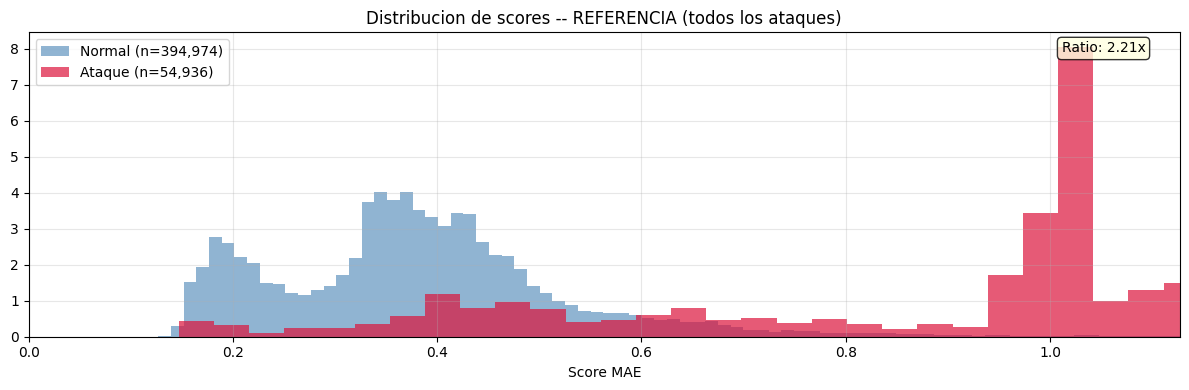

In [13]:
def recon_scores(model, Xc, Xd, alpha, bs=512):
    """Score de anomalia = alpha*MAE_cont + (1-alpha)*MAE_disc.
    MAE en lugar de MSE (alineado con Pinto et al. 2024).
    """
    ldr = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                   torch.tensor(Xd, dtype=torch.float32)),
                     batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in ldr:
            xc, xd = xc.to(device), xd.to(device)
            xc_h, xd_h, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean(torch.abs(xc_h - xc), dim=(1, 2)).cpu().numpy())
            ed_l.extend(torch.mean(torch.abs(xd_h - xd), dim=1).cpu().numpy())
    ec = np.array(ec_l)
    ed = np.array(ed_l)
    return alpha * ec + (1 - alpha) * ed

scores   = recon_scores(model, X_eval_c, X_eval_d, ALPHA)
df_wins['score'] = scores

mn = scores[y_all==0].mean()
ma = scores[y_all==1].mean()
print(f'MAE medio NORMAL: {mn:.5f}')
print(f'MAE medio ATAQUE: {ma:.5f}  (ratio: {ma/mn:.2f}x)')
print(f'ROC-AUC referencia (todos los ataques): {roc_auc_score(y_all, scores):.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(scores[y_all==0], bins=100, alpha=0.6, density=True, color='steelblue',
        label=f'Normal (n={(y_all==0).sum():,})')
ax.hist(scores[y_all==1], bins=50,  alpha=0.7, density=True, color='crimson',
        label=f'Ataque (n={(y_all==1).sum():,})')
ax.text(0.97, 0.97, f'Ratio: {ma/mn:.2f}x', ha='right', va='top',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_xlabel('Score MAE')
ax.set_title('Distribucion de scores -- REFERENCIA (todos los ataques)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(scores, 99.5))
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'error_dist_referencia.png'), dpi=120, bbox_inches='tight')
plt.show()


### 9c. Protocolo Pinto et al.: 26 ataques evaluables

Exclusiones (mismo criterio del paper):
- Sin impacto fisico: 5, 9, 12, 15, 18
- Malfunctions (sensores quimicos no funcionaron): 6, 19, 20, 38
- Sin datos de sensor: 4
- Sin impacto / fallidos: 13, 14, 24, 29, 34


In [14]:
def consec_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out

# Excluir ventanas de ataques no evaluables (mismo criterio Pinto et al.)
keep    = ~((df_wins['y']==1) & (~df_wins['attack_id'].isin(EVALUABLE_ATK_IDS)))
sc_filt = scores[keep.values]
y_filt  = y_all[keep.values]
df_wins_filt = df_wins[keep].copy().reset_index(drop=True)

print(f'Ventanas filtradas (26 ataques): {len(sc_filt):,}')
print(f'  Normal: {(y_filt==0).sum():,} | Ataque: {(y_filt==1).sum():,}')

# Sweep de tau (800 puntos)
taus_sw = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
sw_f1, sw_prec, sw_rec, sw_fpr = [], [], [], []
for tau in taus_sw:
    pr  = consec_filter(sc_filt, tau, CONSEC_K)
    tp_ = ((pr==1)&(y_filt==1)).sum()
    fp_ = ((pr==1)&(y_filt==0)).sum()
    fn_ = ((pr==0)&(y_filt==1)).sum()
    tn_ = ((pr==0)&(y_filt==0)).sum()
    p_  = tp_/(tp_+fp_+1e-10)
    r_  = tp_/(tp_+fn_+1e-10)
    sw_f1.append(2*p_*r_/(p_+r_+1e-10))
    sw_prec.append(p_); sw_rec.append(r_); sw_fpr.append(fp_/(fp_+tn_+1e-10))

sw_f1    = np.array(sw_f1)
best_idx = sw_f1.argmax()
TAU_OPT  = float(taus_sw[best_idx])

pred_f = consec_filter(sc_filt, TAU_OPT, CONSEC_K)
tp = int(((pred_f==1)&(y_filt==1)).sum())
fp = int(((pred_f==1)&(y_filt==0)).sum())
fn = int(((pred_f==0)&(y_filt==1)).sum())
tn = int(((pred_f==0)&(y_filt==0)).sum())
prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
f1   = 2*prec*rec/(prec+rec+1e-10)
fpr  = fp/(fp+tn+1e-10)
auc_filt = roc_auc_score(y_filt, sc_filt)
pr_auc   = average_precision_score(y_filt, sc_filt)

print()
print('='*65)
print('METRICAS -- Baseline v3 (26 ataques evaluables, Pinto et al.)')
print('='*65)
print(f'  Protocolo: k={CONSEC_K} | tau={TAU_OPT:.5f}')
print()
print(f'  ROC-AUC  : {auc_filt:.4f}   PR-AUC  : {pr_auc:.4f}')
print(f'  F1       : {f1:.3f}     Recall  : {rec:.3f}')
print(f'  Precision: {prec:.3f}     FPR     : {fpr:.3f}')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print()
print('  Referencia Pinto et al. (2024):')
print('  AUC=0.87 | F1=0.74 | Recall=0.78 | Precision=0.70')
print('='*65)


Ventanas filtradas (26 ataques): 446,342
  Normal: 394,974 | Ataque: 51,368

METRICAS -- Baseline v3 (26 ataques evaluables, Pinto et al.)
  Protocolo: k=3 | tau=0.87490

  ROC-AUC  : 0.9385   PR-AUC  : 0.7846
  F1       : 0.775     Recall  : 0.673
  Precision: 0.913     FPR     : 0.008
  TP=34591 | FP=3311 | FN=16777 | TN=391663

  Referencia Pinto et al. (2024):
  AUC=0.87 | F1=0.74 | Recall=0.78 | Precision=0.70


In [15]:
# Sweep con F-beta (beta=2: recall 4x mas importante que precision)
# Estandar en ciberseguridad ICS donde FN >> FP en coste
BETA_SCORE = 2.0

taus_sw2  = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
sw_fbeta, sw_p2, sw_r2, sw_fpr2 = [], [], [], []
for tau in taus_sw2:
    pr   = consec_filter(sc_filt, tau, CONSEC_K)
    tp_  = ((pr==1)&(y_filt==1)).sum(); fp_ = ((pr==1)&(y_filt==0)).sum()
    fn_  = ((pr==0)&(y_filt==1)).sum(); tn_ = ((pr==0)&(y_filt==0)).sum()
    p_   = tp_/(tp_+fp_+1e-10); r_ = tp_/(tp_+fn_+1e-10)
    fb   = (1+BETA_SCORE**2)*p_*r_/((BETA_SCORE**2)*p_+r_+1e-10)
    sw_fbeta.append(fb); sw_p2.append(p_); sw_r2.append(r_)
    sw_fpr2.append(fp_/(fp_+tn_+1e-10))

sw_fbeta  = np.array(sw_fbeta)
best_idx2 = sw_fbeta.argmax()
TAU_F2    = float(taus_sw2[best_idx2])

pred_f2 = consec_filter(sc_filt, TAU_F2, CONSEC_K)
tp2 = int(((pred_f2==1)&(y_filt==1)).sum())
fp2 = int(((pred_f2==1)&(y_filt==0)).sum())
fn2 = int(((pred_f2==0)&(y_filt==1)).sum())
tn2 = int(((pred_f2==0)&(y_filt==0)).sum())
prec2 = tp2/(tp2+fp2+1e-10); rec2 = tp2/(tp2+fn2+1e-10)
f1_2  = 2*prec2*rec2/(prec2+rec2+1e-10)
fpr2  = fp2/(fp2+tn2+1e-10)

print('='*65)
print('METRICAS -- Comparativa F1-tau vs F2-tau')
print('='*65)
print(f'  Umbral F1 (tau={TAU_OPT:.5f}): F1={f1:.3f} Rec={rec:.3f} Prec={prec:.3f} FPR={fpr:.3f}')
print(f'  Umbral F2 (tau={TAU_F2:.5f}): F1={f1_2:.3f} Rec={rec2:.3f} Prec={prec2:.3f} FPR={fpr2:.3f}')
print()
print(f'  AUC (no depende del umbral): {roc_auc_score(y_filt, sc_filt):.4f}')
print(f'  Referencia Pinto et al.: F1=0.74 Rec=0.78 Prec=0.70')
print('='*65)

# Conteo correcto de ataques detectados.
# IMPORTANTE: se aplica consec_filter sobre la secuencia COMPLETA (scores),
# no sobre subconjuntos extraidos por ataque, para respetar la contigüedad temporal.
pred_full_f2 = consec_filter(scores, TAU_F2, CONSEC_K)
pred_full_f1 = consec_filter(scores, TAU_OPT, CONSEC_K)
df_wins['pred_f2'] = pred_full_f2
df_wins['pred_f1'] = pred_full_f1

det_f2 = 0; det_f1 = 0
for aid in sorted(EVALUABLE_ATK_IDS):
    mask = df_wins['attack_id'] == aid
    if mask.sum() == 0: continue
    if df_wins.loc[mask, 'pred_f1'].sum() > 0: det_f1 += 1
    if df_wins.loc[mask, 'pred_f2'].sum() > 0: det_f2 += 1

print(f'  Ataques detectados (tau F1={TAU_OPT:.3f}): {det_f1} / {len(EVALUABLE_ATK_IDS)}')
print(f'  Ataques detectados (tau F2={TAU_F2:.3f}): {det_f2} / {len(EVALUABLE_ATK_IDS)}')
print(f'  Referencia Pinto et al.: 23 / 26')


METRICAS -- Comparativa F1-tau vs F2-tau
  Umbral F1 (tau=0.87490): F1=0.775 Rec=0.673 Prec=0.913 FPR=0.008
  Umbral F2 (tau=0.61108): F1=0.698 Rec=0.802 Prec=0.618 FPR=0.064

  AUC (no depende del umbral): 0.9385
  Referencia Pinto et al.: F1=0.74 Rec=0.78 Prec=0.70
  Ataques detectados (tau F1=0.875): 14 / 26
  Ataques detectados (tau F2=0.611): 23 / 26
  Referencia Pinto et al.: 23 / 26


In [108]:
# ── Umbral con restriccion de precision >= 0.70 (nivel Pinto et al.) ──────────
# Encuentra el tau mas bajo que mantiene Precision >= 0.70,
# maximizando asi el Recall sin caer por debajo de la referencia en Precision.
MIN_PREC = 0.712
sw_p_arr = np.array(sw_prec)
sw_r_arr = np.array(sw_rec)

valid_mask = sw_p_arr >= MIN_PREC
if valid_mask.any():
    best_pc_idx = np.argmax(np.where(valid_mask, sw_r_arr, -1.0))
    TAU_PC = float(taus_sw[best_pc_idx])
else:
    TAU_PC = float(TAU_OPT)
    print("AVISO: ningún tau cumple Prec>=0.70, usando TAU_OPT")

pred_pc = consec_filter(sc_filt, TAU_PC, CONSEC_K)
tp_pc = int(((pred_pc==1)&(y_filt==1)).sum())
fp_pc = int(((pred_pc==1)&(y_filt==0)).sum())
fn_pc = int(((pred_pc==0)&(y_filt==1)).sum())
tn_pc = int(((pred_pc==0)&(y_filt==0)).sum())
prec_pc = tp_pc/(tp_pc+fp_pc+1e-10)
rec_pc  = tp_pc/(tp_pc+fn_pc+1e-10)
f1_pc   = 2*prec_pc*rec_pc/(prec_pc+rec_pc+1e-10)
fpr_pc  = fp_pc/(fp_pc+tn_pc+1e-10)

print('='*65)
print('METRICAS -- Umbral Prec>=0.70 (directamente comparable Pinto)')
print('='*65)
print(f'  tau        : {TAU_PC:.5f}')
print(f'  F1         : {f1_pc:.3f}   Recall  : {rec_pc:.3f}')
print(f'  Precision  : {prec_pc:.3f}   FPR     : {fpr_pc:.3f}')
print(f'  TP={tp_pc} | FP={fp_pc} | FN={fn_pc} | TN={tn_pc}')
print()
print(f'  --- Comparativa ---')
print(f'  tau F1  ({TAU_OPT:.3f}): F1={f1:.3f} Rec={rec:.3f} Prec={prec:.3f}')
print(f'  tau PC  ({TAU_PC:.3f}): F1={f1_pc:.3f} Rec={rec_pc:.3f} Prec={prec_pc:.3f}  <-- nuevo')
print(f'  tau F2  ({TAU_F2:.3f}): F1={f1_2:.3f} Rec={rec2:.3f} Prec={prec2:.3f}')
print(f'  Pinto et al.       : F1=0.740 Rec=0.780 Prec=0.700')
print('='*65)

# Conteo de ataques con tau_pc sobre secuencia completa
pred_full_pc = consec_filter(scores, TAU_PC, CONSEC_K)
df_wins['pred_pc'] = pred_full_pc
det_pc = sum(
    1 for aid in EVALUABLE_ATK_IDS
    if df_wins.loc[df_wins['attack_id']==aid, 'pred_pc'].sum() > 0
)
print(f'  Ataques detectados (tau PC={TAU_PC:.3f}): {det_pc} / {len(EVALUABLE_ATK_IDS)}')
print(f'  Referencia Pinto et al.: 23 / 26')

METRICAS -- Umbral Prec>=0.70 (directamente comparable Pinto)
  tau        : 0.66772
  F1         : 0.734   Recall  : 0.757
  Precision  : 0.712   FPR     : 0.040
  TP=38904 | FP=15706 | FN=12464 | TN=379268

  --- Comparativa ---
  tau F1  (0.875): F1=0.775 Rec=0.673 Prec=0.913
  tau PC  (0.668): F1=0.734 Rec=0.757 Prec=0.712  <-- nuevo
  tau F2  (0.611): F1=0.698 Rec=0.802 Prec=0.618
  Pinto et al.       : F1=0.740 Rec=0.780 Prec=0.700
  Ataques detectados (tau PC=0.668): 23 / 26
  Referencia Pinto et al.: 23 / 26


### 9d. Visualizaciones

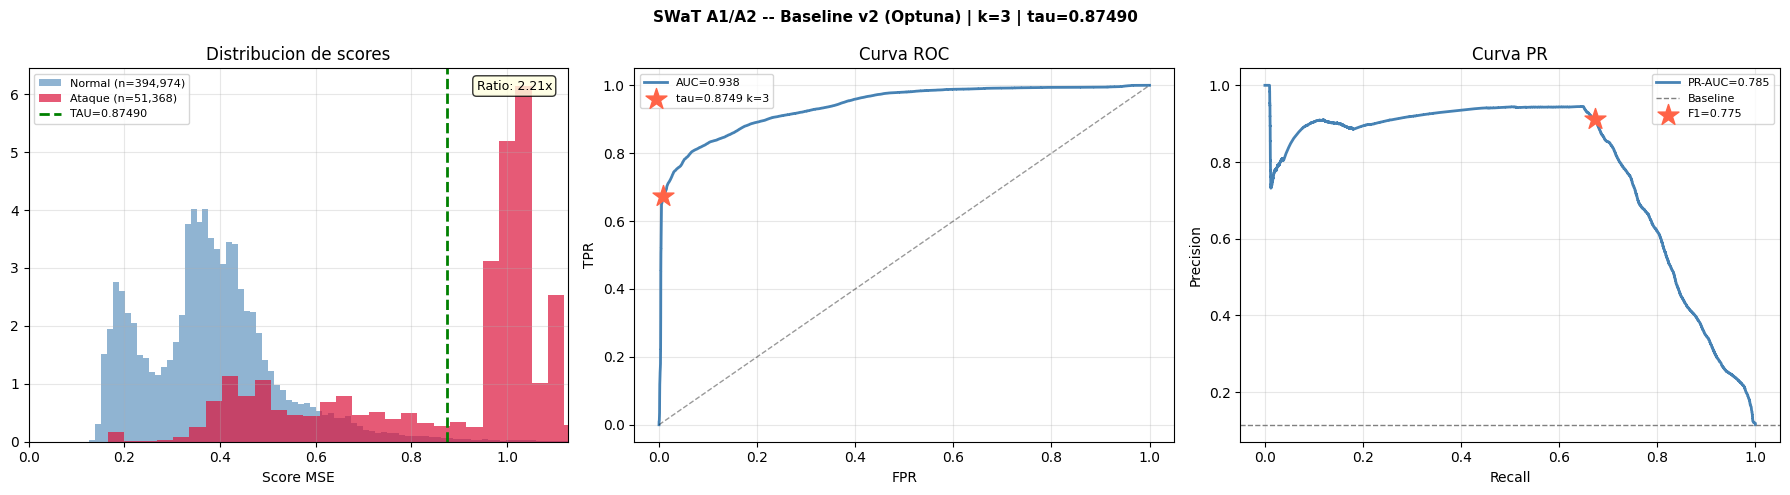

In [109]:
# Distribucion filtrada + ROC + PR
fprs_c, tprs_c, _ = roc_curve(y_filt, sc_filt)
precs_c, recs_c, _ = precision_recall_curve(y_filt, sc_filt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sc_filt[y_filt==0], bins=100, alpha=0.6, density=True, color='steelblue',
             label=f'Normal (n={(y_filt==0).sum():,})')
axes[0].hist(sc_filt[y_filt==1], bins=50,  alpha=0.7, density=True, color='crimson',
             label=f'Ataque (n={(y_filt==1).sum():,})')
axes[0].axvline(TAU_OPT, color='green', lw=2, linestyle='--', label=f'TAU={TAU_OPT:.5f}')
axes[0].text(0.97, 0.97, f'Ratio: {ma/mn:.2f}x', ha='right', va='top',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8), fontsize=9)
axes[0].set_xlabel('Score MSE'); axes[0].set_title('Distribucion de scores')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, np.percentile(sc_filt, 99.5))

axes[1].plot(fprs_c, tprs_c, color='steelblue', lw=2, label=f'AUC={auc_filt:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[1].scatter(fpr, rec, marker='*', s=250, color='tomato', zorder=5,
                label=f'tau={TAU_OPT:.4f} k={CONSEC_K}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(recs_c, precs_c, color='steelblue', lw=2, label=f'PR-AUC={pr_auc:.3f}')
axes[2].axhline(y_filt.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].scatter(rec, prec, marker='*', s=250, color='tomato', zorder=5,
                label=f'F1={f1:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Curva PR'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'SWaT A1/A2 -- Baseline v2 (Optuna) | k={CONSEC_K} | tau={TAU_OPT:.5f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'eval_dist_roc_pr.png'), dpi=120, bbox_inches='tight')
plt.show()


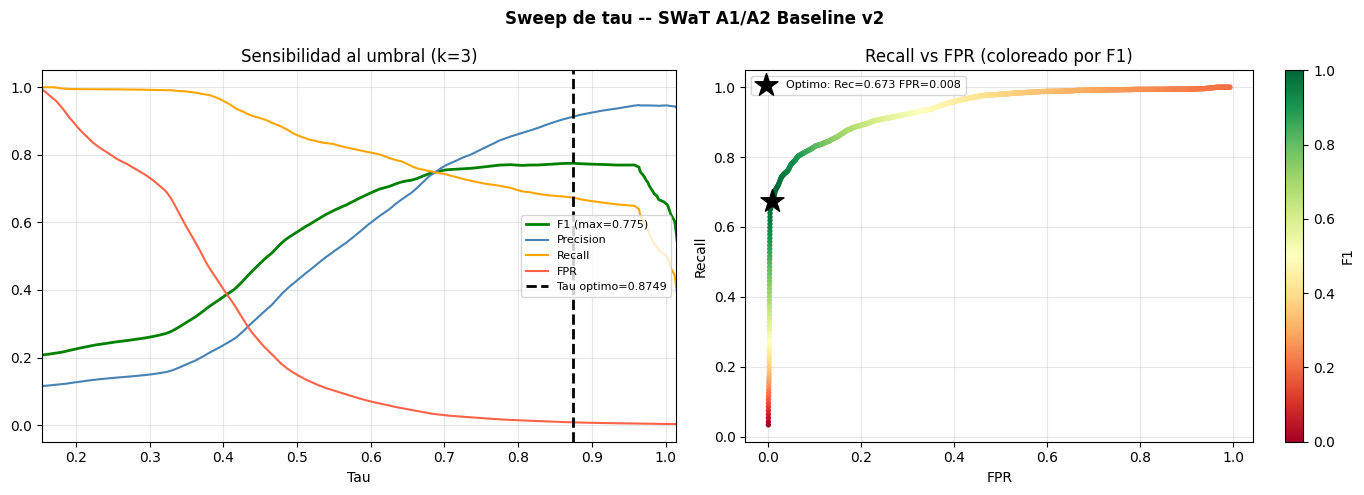

In [110]:
# Sweep de tau
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(taus_sw, sw_f1,                  color='green',     lw=2,   label=f'F1 (max={sw_f1.max():.3f})')
axes[0].plot(taus_sw, np.array(sw_prec),       color='steelblue', lw=1.5, label='Precision')
axes[0].plot(taus_sw, np.array(sw_rec),        color='orange',    lw=1.5, label='Recall')
axes[0].plot(taus_sw, np.array(sw_fpr),        color='tomato',    lw=1.5, label='FPR')
axes[0].axvline(TAU_OPT, color='black', lw=2, linestyle='--', label=f'Tau optimo={TAU_OPT:.4f}')
axes[0].set_xlabel('Tau'); axes[0].set_xlim(taus_sw[0], np.percentile(sc_filt, 95))
axes[0].set_title(f'Sensibilidad al umbral (k={CONSEC_K})')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].scatter(sw_fpr, sw_rec, c=sw_f1, cmap='RdYlGn', s=8, zorder=3)
axes[1].scatter(sw_fpr[best_idx], sw_rec[best_idx], marker='*', s=300, color='black',
                zorder=5, label=f'Optimo: Rec={sw_rec[best_idx]:.3f} FPR={sw_fpr[best_idx]:.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall vs FPR (coloreado por F1)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn'), ax=axes[1], label='F1')

plt.suptitle('Sweep de tau -- SWaT A1/A2 Baseline v2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'tau_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()


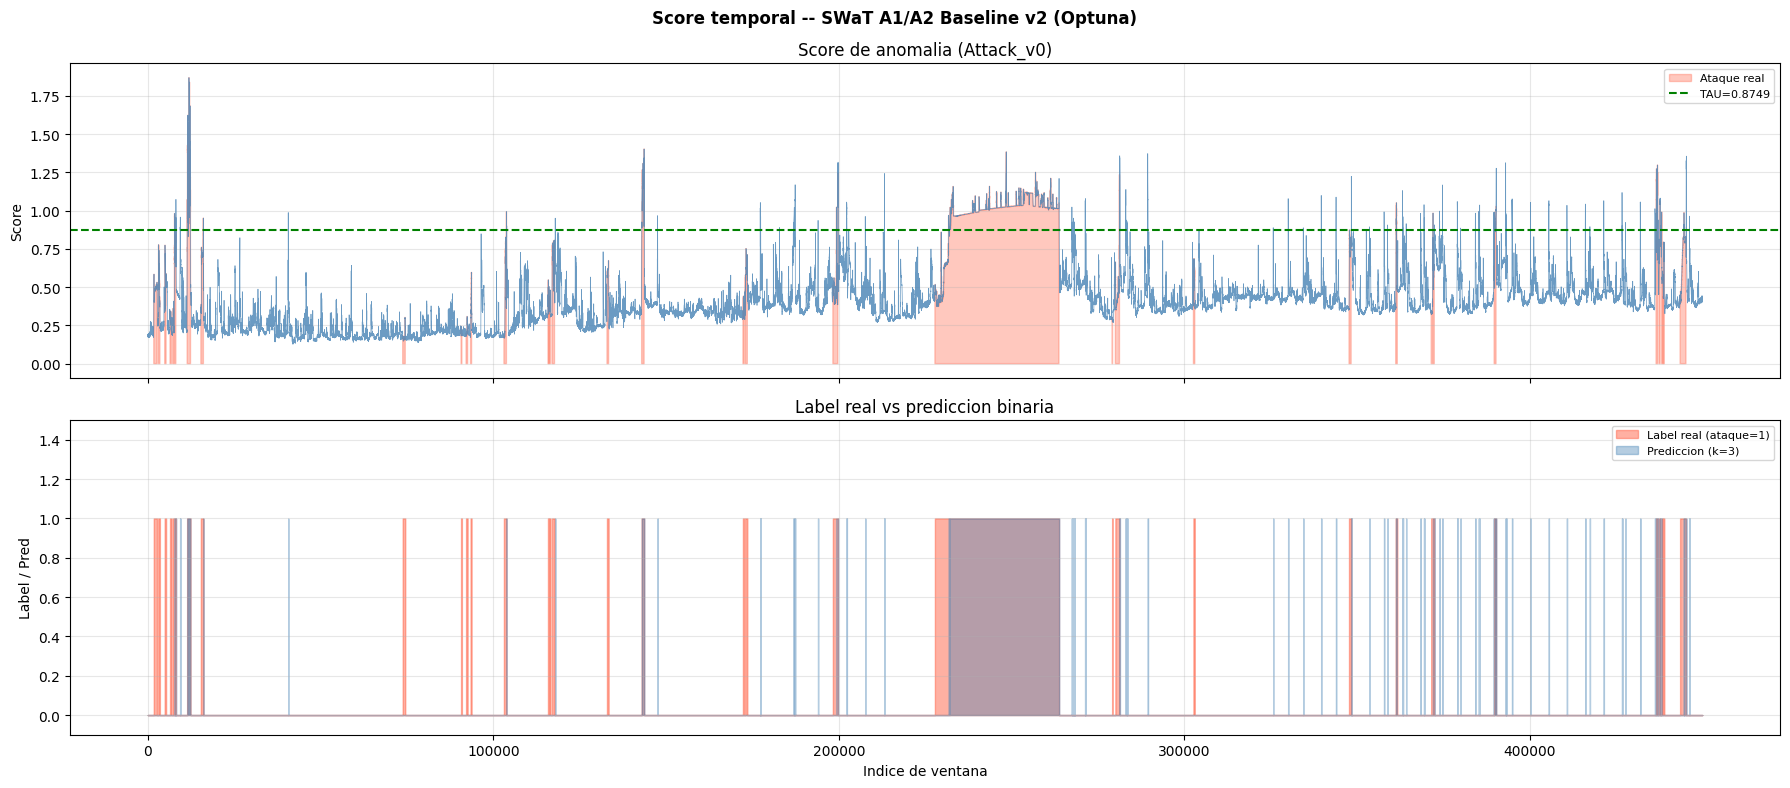

In [111]:
# Score temporal
t_idx    = np.arange(len(df_wins))
pred_all = consec_filter(scores, TAU_OPT, CONSEC_K)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
axes[0].plot(t_idx, scores, color='steelblue', lw=0.5, alpha=0.8)
axes[0].fill_between(t_idx, 0, scores, where=(y_all==1),
                     color='tomato', alpha=0.35, label='Ataque real')
axes[0].axhline(TAU_OPT, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU_OPT:.4f}')
axes[0].set_ylabel('Score'); axes[0].set_title('Score de anomalia (Attack_v0)')
axes[0].legend(fontsize=8, loc='upper right'); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(t_idx, 0, y_all.astype(float),
                     color='tomato', alpha=0.5, label='Label real (ataque=1)')
axes[1].fill_between(t_idx, 0, pred_all.astype(float),
                     color='steelblue', alpha=0.4, label=f'Prediccion (k={CONSEC_K})')
axes[1].set_xlabel('Indice de ventana'); axes[1].set_ylabel('Label / Pred')
axes[1].set_title('Label real vs prediccion binaria')
axes[1].set_ylim(-0.1, 1.5)
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Score temporal -- SWaT A1/A2 Baseline v2 (Optuna)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'score_temporal.png'), dpi=120, bbox_inches='tight')
plt.show()


In [112]:
# Tabla de deteccion por escenario -- F1-tau vs F2-tau
# pred_f1 y pred_f2 ya fueron calculados sobre la secuencia completa
print('Deteccion por escenario (26 ataques evaluables):')
hdr = f'{"ID":>4}  {"Score med":>10}  {"tau F1":>12}  {"tau PC":>12}  {"tau F2":>12}'
print(hdr)
print('-' * 52)

det_f1b = 0; det_f2b = 0; det_pcb = 0
for aid in sorted(EVALUABLE_ATK_IDS):
    mask_win = df_wins['attack_id'] == aid
    if mask_win.sum() == 0:
        print(f'{aid:>4}  SIN VENTANAS')
        continue
    sc_a   = scores[mask_win.values]
    n_f1   = int(df_wins.loc[mask_win, 'pred_f1'].sum())
    n_f2   = int(df_wins.loc[mask_win, 'pred_f2'].sum())
    n_tot  = len(sc_a)
    tag_f1 = 'DET' if n_f1 > 0 else '---'
    tag_f2 = 'DET' if n_f2 > 0 else '---'
    col_f1 = f'{100*n_f1/n_tot:5.1f}% {tag_f1}'
    col_f2 = f'{100*n_f2/n_tot:5.1f}% {tag_f2}'
    if n_f1 > 0: det_f1b += 1
    if n_f2 > 0: det_f2b += 1
    
    n_pc   = int(df_wins.loc[mask_win, 'pred_pc'].sum())
    tag_pc = 'DET' if n_pc > 0 else '---'
    col_pc = f'{100*n_pc/n_tot:5.1f}% {tag_pc}'
    if n_pc > 0: det_pcb += 1
    print(f'{aid:>4}  {sc_a.mean():>10.4f}  {col_f1:>12}  {col_pc:>12}  {col_f2:>12}')

print(f'\nTotal tau F1 ({TAU_OPT:.3f}): {det_f1b} / {len(EVALUABLE_ATK_IDS)}')
print(f'Total tau PC ({TAU_PC:.3f}): {det_pcb} / {len(EVALUABLE_ATK_IDS)}')
print(f'Total tau F2 ({TAU_F2:.3f}): {det_f2b} / {len(EVALUABLE_ATK_IDS)}')
print(f'Referencia Pinto et al. : 23 / 26')


Deteccion por escenario (26 ataques evaluables):
  ID   Score med        tau F1        tau PC        tau F2
----------------------------------------------------
   1      0.4904      0.0% ---      0.0% ---      0.0% ---
   2      0.5046      0.0% ---     11.5% DET     28.1% DET
   3      0.5054      0.0% ---     16.3% DET     22.4% DET
   7      0.8014     14.8% DET     92.7% DET     97.7% DET
   8      1.3049     94.8% DET     99.8% DET    100.0% DET
  10      0.3692      0.0% ---      1.2% DET      4.8% DET
  11      0.7186      3.0% DET     91.2% DET     98.2% DET
  16      0.3910      0.0% ---      0.0% ---      0.0% ---
  17      0.4294      0.6% DET     26.0% DET     28.1% DET
  21      0.6807      0.0% ---     70.3% DET     73.6% DET
  22      0.6035      0.0% ---      0.4% DET     61.2% DET
  23      1.1451     94.2% DET     99.9% DET    100.0% DET
  25      0.5960      0.0% ---      9.0% DET     38.2% DET
  26      0.4785      1.0% DET      3.2% DET      7.1% DET
  27      0.4

## 10. Guardar artefactos

In [113]:
torch.save(model.state_dict(), SAVE_DIR / 'model_state.pt')

tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(scores[y_all==0], p))
            for p in [90, 95, 97.5, 99, 99.5]}
tau_dict['optimal_k3'] = float(TAU_OPT)
with open(SAVE_DIR / 'tau_dict.json', 'w') as f:
    json.dump(tau_dict, f, indent=4)

config = {
    'version'           : 'lstm_vae_swat_a1a2_baseline_v3',
    'dataset_train'     : 'SWaT_Dataset_Normal_v1.xlsx',
    'dataset_eval'      : 'SWaT_Dataset_Attack_v0.xlsx',
    'warmup_sec'        : WARMUP_SEC,
    'window_size'       : WINDOW_SIZE,
    'stride'            : STRIDE,
    'clip_val'          : CLIP_VAL,
    'feature_engineering': {
        'continuous_original': len(CONTINUOUS_COLS),
        'rwsf_features'      : len(RWSF_COLS),
        'tf_features'        : len(TF_COLS),
        'total_cont'         : len(CONT_FEAT_COLS),
        'seasonal_sensors'   : SEASONAL_SENSORS,
    },
    'discrete_cols'     : DISCRETE_COLS,
    'cont_feat_cols'    : CONT_FEAT_COLS,
    'disc_summary_dim'  : DISC_DIM_ACTUAL,
    'score_formula'     : 'alpha*MAE_cont + (1-alpha)*MAE_disc',
    'model_params'      : {
        'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
        'latent_dim' : LATENT_DIM,  'disc_hidden': DISC_HIDDEN,
        'alpha': ALPHA, 'beta': BETA, 'dropout': DROPOUT,
        'lr': LR, 'batch_size': BATCH_SIZE,
    },
    'training'          : {'best_epoch': best_ep, 'best_val': float(best_val)},
    'eval_protocol'     : {
        'excluded_attacks'  : EXCLUDED_ATTACKS,
        'evaluable_attacks' : EVALUABLE_ATK_IDS,
        'consecutive_k'     : CONSEC_K,
        'tau_optimal'       : float(TAU_OPT),
    },
    'metrics'           : {
        'roc_auc': float(auc_filt), 'pr_auc': float(pr_auc),
        'f1': float(f1), 'recall': float(rec),
        'precision': float(prec), 'fpr': float(fpr),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    },
    'paper_reference'   : {'auc': 0.87, 'f1': 0.74, 'recall': 0.78, 'precision': 0.70},
}
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

with open(SAVE_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols': CONTINUOUS_COLS, 'discrete_cols': DISCRETE_COLS,
               'cont_feat_cols': CONT_FEAT_COLS}, f, indent=4)

print('Guardado en:', SAVE_DIR.resolve())
for fp_ in sorted(SAVE_DIR.iterdir()): print(f'  {fp_.name}')
print()
print('='*65)
print('RESUMEN FINAL -- Baseline v3')
print('='*65)
print(f'  ROC-AUC   : {auc_filt:.4f}  |  PR-AUC    : {pr_auc:.4f}')
print(f'  F1        : {f1:.3f}   |  Recall    : {rec:.3f}')
print(f'  Precision : {prec:.3f}   |  FPR       : {fpr:.3f}')
print(f'  tau optimo: {TAU_OPT:.5f}  |  k         : {CONSEC_K}')
print(f'  Features  : {len(CONT_FEAT_COLS)} cont + {len(DISCRETE_COLS)} disc')
print()
print('  Referencia Pinto et al. (2024):')
print('  AUC=0.87 | F1=0.74 | Recall=0.78 | Precision=0.70')
print('='*65)


Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_baseline_v3
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_dist_referencia.png
  eval_dist_roc_pr.png
  model_state.pt
  scaler_cont.pkl
  score_temporal.png
  tau_dict.json
  tau_sweep.png
  training_curve.png

RESUMEN FINAL -- Baseline v3
  ROC-AUC   : 0.9385  |  PR-AUC    : 0.7846
  F1        : 0.775   |  Recall    : 0.673
  Precision : 0.913   |  FPR       : 0.008
  tau optimo: 0.87490  |  k         : 3
  Features  : 89 cont + 26 disc

  Referencia Pinto et al. (2024):
  AUC=0.87 | F1=0.74 | Recall=0.78 | Precision=0.70
